# Μέρος 1: Παρακολούθηση Προσώπου και Χεριών με Χρήση της Μεθόδου Οπτικής Ροής των Lucas-Kanade

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage, io
import os

## 1.1 Ανίχνευση Δέρματος Προσώπου και Χεριών

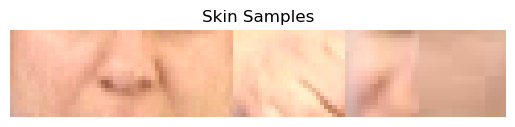

In [2]:
# Load skin samples and convert to YCbCr
mat = io.loadmat('part1_data/skinSamplesRGB.mat')
skinSamples = np.array(mat['skinSamplesRGB'])

plt.title('Skin Samples')
plt.imshow(skinSamples)
plt.axis('off')
plt.show()

skinSamples = cv2.cvtColor(skinSamples, cv2.COLOR_RGB2YCrCb)
del mat

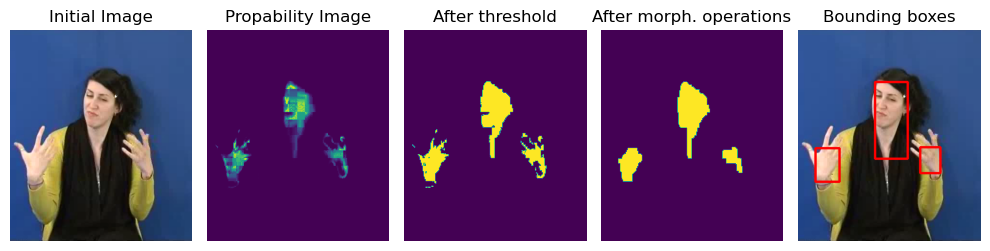

In [3]:
# Load first frame
imageRGB = cv2.imread('part1_data/1.png')
imageRGB = cv2.cvtColor(imageRGB, cv2.COLOR_BGR2RGB)
imageYCbCr = cv2.cvtColor(imageRGB, cv2.COLOR_RGB2YCrCb)
c = np.array([imageYCbCr[:,:,1].flatten(), imageYCbCr[:,:,2].flatten()])

# Calculate mean value and covariance matrix
Cb = skinSamples[:,:,1].flatten()
Cr = skinSamples[:,:,2].flatten()
mean_Cb = np.mean(Cb)
mean_Cr = np.mean(Cr)
mu = np.array([mean_Cb, mean_Cr])
sigma = np.cov(Cb, Cr)

# Calculate propability image
prob_image = stats.multivariate_normal(mean=mu, cov=sigma).pdf(c.T)
prob_image = prob_image.reshape(imageRGB.shape[0], imageRGB.shape[1])

# Apply threshold
_, prob_thres = cv2.threshold(prob_image, 0.0005, 1, cv2.THRESH_BINARY)

# Apply opening, then closing
open_kernel = np.ones((7, 7))
close_kernel = np.ones((20, 20), np.uint8)
prob_morph = cv2.morphologyEx(prob_thres, cv2.MORPH_OPEN, open_kernel)
prob_morph = cv2.morphologyEx(prob_morph, cv2.MORPH_CLOSE, close_kernel)
prob_morph = (prob_morph * 255).astype('uint8')

# Draw bounding boxes
image_out = imageRGB.copy()
_, contours, _ = cv2.findContours(prob_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 3)

# Plot steps
plt.figure(figsize=(10, 3))
plt.subplot(1,5,1)
plt.title('Initial Image')
plt.imshow(imageRGB)
plt.axis('off')
plt.subplot(1,5,2)
plt.title('Propability Image')
plt.imshow(prob_image)
plt.axis('off')
plt.subplot(1,5,3)
plt.title('After threshold')
plt.imshow(prob_thres)
plt.axis('off')
plt.subplot(1,5,4)
plt.title('After morph. operations')
plt.imshow(prob_morph)
plt.axis('off')
plt.subplot(1,5,5)
plt.title('Bounding boxes')
plt.imshow(image_out)
plt.axis('off')
plt.tight_layout()
plt.show()

del imageRGB, imageYCbCr, c, prob_image, prob_thres, prob_morph, image_out, contours

Compose final function:

In [4]:
def SkinDetect(image, mean, cov):
    # Convert to YCbCr
    imageYCbCr = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)

    # Calculate propability image
    c = np.array([imageYCbCr[:,:,1].flatten(), imageYCbCr[:,:,2].flatten()])
    prob_image = stats.multivariate_normal(mean, cov).pdf(c.T)
    prob_image = prob_image.reshape(image.shape[0], image.shape[1])

    # Apply threshold
    _, prob_thres = cv2.threshold(prob_image, 0.0005, 1, cv2.THRESH_BINARY)

    # Apply morphological operations
    open_kernel = np.ones((7, 7))
    close_kernel = np.ones((20, 20), np.uint8)
    prob_morph = cv2.morphologyEx(prob_thres, cv2.MORPH_OPEN, open_kernel)
    prob_morph = cv2.morphologyEx(prob_morph, cv2.MORPH_CLOSE, close_kernel)
    prob_morph = (prob_morph * 255).astype('uint8')

    # Draw bounding boxes
    _, contours, _ = cv2.findContours(prob_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = [cv2.boundingRect(contour) for contour in contours]
    return bounding_boxes

## 1.2 Παρακολούθηση Προσώπου και Χεριών

Κατασκευάσουμε τα κατάλληλα δεδομένα εισόδου. Καθώς τα πλαίσια της εκφώνησης είναι λανθασμένα, χρησιμοποιώ τη συνάρτηση SkinDetect(), διευρύνοντας τα παράθυρα

In [5]:
# Load first 2 frames
frame1 = cv2.imread('part1_data/1.png')
frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2 = cv2.imread('part1_data/2.png')
frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

# bounding_boxes = [[93, 272, 56, 83], [201, 270, 56, 83], [154, 102, 67, 115]] #left hand, right hand, head
bounding_boxes = SkinDetect(frame1, mu, sigma)
enlarge = [-10, -10, +20, +20]

# Work with two frames of the left hand
x, y, w, h = np.array(bounding_boxes[0]) + np.array(enlarge)
frame1 = frame1[y:y+h, x:x+w]
frame2 = frame2[y:y+h, x:x+w]

# Convert to grayscale
frame1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
frame2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

# Detect corners
corners = cv2.goodFeaturesToTrack(frame2, maxCorners=100, qualityLevel=0.01, minDistance=10)

Υλοποιούμε τον αλγόριθμο Lucas-Kanade

(-0.5, 89.5, 109.5, -0.5)

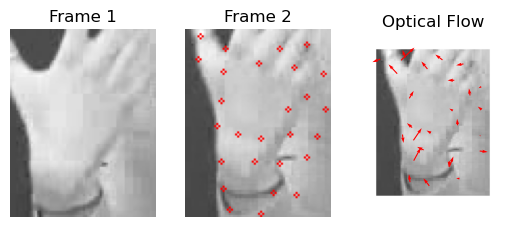

In [6]:
def LucasKanade(image1, image2, features, rho, epsilon, d_x0, d_y0):
    # Convert features to a more usable format
    features = np.squeeze(features.astype(int))

    # Normalize images
    image1 = image1/255
    image2 = image2/255
    
    # initialize result vector
    d = np.zeros((2, features.shape[0]))

    # Get Gaussian Kernel
    size = int(2*np.ceil(3*rho)+1)
    Gp = cv2.getGaussianKernel(size, rho)
    Gp = Gp @ Gp.T
    mid = (size-1)//2
    
    for i, feature in enumerate(features):
        x, y = feature
        d_x = d_x0[i]
        d_y = d_y0[i]

        # Get area around the feature
        I1 = image1[max(0, y-mid):min(y+mid, image1.shape[0]),
                    max(0, x-mid):min(x+mid, image1.shape[1])]
        I2 = image2[max(0, y-mid):min(y+mid, image2.shape[0]),
                    max(0, x-mid):min(x+mid, image2.shape[1])]
        I1_grad_y, I1_grad_x = np.gradient(I1)

        # Update mid (in case the feature is close to the border)
        try:
            mid_area = mid
            _ = I1[mid_area, mid_area]
        except(IndexError):
            mid_area = min((I1.shape[0]-1)//2, (I1.shape[1]-1)//2)

        u = np.array([[float('inf')], [float('inf')]])
        for j in range(150):
            # Convergence criterion
            if np.linalg.norm(u) < 0.001:
                break

            # Calculate shifted images
            x_0, y_0 = np.meshgrid(np.arange(I1.shape[1]), np.arange(I1.shape[0]))
            I1_shifted = ndimage.map_coordinates(I1,[y_0+d_y, x_0+d_x], order=1).reshape(I1.shape)
            I1_grad_x_shifted = ndimage.map_coordinates(I1_grad_x,[y_0+d_y, x_0+d_x], order=1).reshape(I1.shape)
            I1_grad_y_shifted = ndimage.map_coordinates(I1_grad_y,[y_0+d_y, x_0+d_x], order=1).reshape(I1.shape)

            # Calculate helper matrices
            A1 = I1_grad_x_shifted
            A2 = I1_grad_y_shifted
            E = I2 - I1_shifted

            #Lucas-Kanade Matrices
            mat1_11 = cv2.filter2D(A1**2, -1, Gp)[mid_area,mid_area] + epsilon
            mat1_12 = cv2.filter2D(A1*A2, -1, Gp)[mid_area,mid_area]
            mat2_22 = cv2.filter2D(A2**2, -1, Gp)[mid_area,mid_area] + epsilon
            mat2_1 = cv2.filter2D(A1*E, -1, Gp)[mid_area,mid_area]
            mat2_2 = cv2.filter2D(A2*E, -1, Gp)[mid_area,mid_area]
            mat1 = np.array([[mat1_11, mat1_12],
                            [mat1_12, mat2_22]])
            mat2 = np.array([[mat2_1],
                            [mat2_2]])
            
            # Calculate u
            u = np.linalg.solve(mat1, mat2)

            # Update the displacement estimates
            d_x += u[0]
            d_y += u[1]
        d[0, i] = d_x
        d[1, i] = d_y
    return d

# Test function
d_x0, d_y0 = np.zeros(corners.shape[0]), np.zeros(corners.shape[0])
[d_x, d_y] = LucasKanade(frame1, frame2, corners, rho=3, epsilon=0.01, d_x0=d_x0, d_y0=d_y0)

# Create plot images
frame2_corners = frame2.copy()
frame2_corners = cv2.cvtColor(frame2_corners, cv2.COLOR_GRAY2RGB)
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(frame2_corners, (int(x), int(y)), 1, (255, 0, 0))
x, y = zip(*[corner.ravel() for corner in corners])
frame1RGB = cv2.cvtColor(frame1, cv2.COLOR_GRAY2RGB)
frame2RGB = cv2.cvtColor(frame2, cv2.COLOR_GRAY2RGB)

# Plot the images
plt.subplot(1,3,1)
plt.imshow(frame1RGB)
plt.title('Frame 1')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(frame2_corners)
plt.axis('off')
plt.title('Frame 2')
plt.subplot(1,3,3)
plt.title("Optical Flow")
plt.imshow(cv2.copyMakeBorder(frame2RGB, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(255, 255, 255)))
plt.quiver(x-d_x+10, y-d_y+10, -d_x, -d_y, angles='xy', color='r')
plt.axis('off')

Υλοποιούμε τη συνάρτηση υπολογισμού μέσης ροής

In [7]:
def displ(d_x, d_y, method='threshold'):
    if method=='threshold':
        threshold = 3
        d = np.array([d_x, d_y])
        mean_energy = np.mean(np.linalg.norm(d, axis=0)**2)
        criterion = (np.abs(np.linalg.norm(d, axis=0)**2 - mean_energy) < threshold*mean_energy)
        d = d[:, criterion]
        return np.mean(d[0]), np.mean(d[1])
    elif method=='mean':
        return np.mean(d_x), np.mean(d_y)
    else:
        return None
    
# Test function
[displ_x, displ_y] = displ(d_x, d_y, method='threshold')
displ_x, displ_y

(1.305065613037902, 2.36463997803808)

Εφαρμόζουμε όλα τα παραπάνω σε ολόκληρη την ακολουθία εικόνων

In [8]:
# def TrackSkin(rho=1, epsilon=0.1):
#     # (rho in [1,5], epsilon in [0.01, 0.1])

#     # Load first 2 frames
#     frame1 = cv2.imread('part1_data/1.png')
#     frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
#     frame2 = cv2.imread('part1_data/2.png')
#     frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

#     # Find initial bounding boxes
#     bounding_boxes = SkinDetect(frame1, mu, sigma)
#     enlarge = [-10, -10, +20, +20]
#     bounding_boxes = np.array(bounding_boxes) + np.array(enlarge)

#     # Draw bounding boxes and optical flow
#     image_out = frame1.copy()
#     for box in bounding_boxes:
#         x, y, w, h = box
#         cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
#     dir_path = f'part1_output/1_2_2/p{rho}_e{epsilon}'.replace('.', '')
#     if not os.path.exists(dir_path):
#         os.makedirs(dir_path)
#     image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
#     cv2.imwrite(dir_path + '/1.png', image_out)

#     # Find optical flow for each bounding box, on each frame
#     i=1
#     while True:
#         # Load first 2 frames
#         frame1 = cv2.imread(f'part1_data/{i}.png')
#         frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
#         frame2 = cv2.imread(f'part1_data/{i+1}.png')
#         if frame2 is None: break
#         frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
#         image_out = frame2.copy()

#         for box in bounding_boxes:
#             # Select frame
#             x, y, w, h = box
#             frame1_box = frame1[y:y+h, x:x+w]
#             frame2_box = frame2[y:y+h, x:x+w]

#             # Convert to grayscale
#             frame1_box = cv2.cvtColor(frame1_box, cv2.COLOR_RGB2GRAY)
#             frame2_box = cv2.cvtColor(frame2_box, cv2.COLOR_RGB2GRAY)

#             # Detect corners
#             corners = cv2.goodFeaturesToTrack(frame2_box, maxCorners=100, qualityLevel=0.01, minDistance=10)

#             # Run Lucas-Kanade
#             d_x0, d_y0 = np.zeros(corners.shape[0]), np.zeros(corners.shape[0])
#             [d_x, d_y] = LucasKanade(frame1_box, frame2_box, corners, rho=rho, epsilon=epsilon, d_x0=d_x0, d_y0=d_y0) #rho=[1,5], epsilon=[0.01, 0.1]

#             # Calculate mean flow
#             [displ_x, displ_y] = displ(d_x, d_y, method='threshold')

#             # Update bounding box
#             box -= np.array([int(displ_x), int(displ_y), 0, 0])
#             box[box<0] = 0

#             # Draw new bounding box and optical flow
#             x, y, w, h = box
#             cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
#             x, y = x+(w//2), y+(h//2)
#             cv2.arrowedLine(image_out, (int(x+displ_x), int(y+displ_y)), (x, y), (255, 0, 0), 1)

#         # Save image
#         image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
#         cv2.imwrite(dir_path+f'/{i+1}.png', image_out)

#         # print(f"frame {i+1} done")
#         i+=1

# rhos = [1, 3, 5]
# epsilons = [0.01, 0.05, 0.1]
# for rho in rhos:
#     for epsilon in epsilons:
#         print(f"Running for rho={rho}, epsilon={epsilon}")
#         TrackSkin(rho=rho, epsilon=epsilon)

In [9]:
def MultiScaleLucasKanade(I1, I2, features, rho, epsilon, d_x0, d_y0, num_levels=3):
    # Create Gaussian pyramids
    pyramid1 = [I1]
    pyramid2 = [I2]
    for i in range(num_levels - 1):
        pyramid1.append(cv2.pyrDown(pyramid1[i]))
        pyramid2.append(cv2.pyrDown(pyramid2[i]))

    # Initialize displacement vectors
    num_features = len(features) if features is not None else 0
    if num_features == 0: print("No features given!")
    d_x, d_y = np.zeros(num_features), np.zeros(num_features)

    # Apply Lucas-Kanade for each level
    for i in range(num_levels - 1, -1, -1):
        # Scale features
        scaled_features = features / (2 ** i)

        # Apply Lucas-Kanade
        d_x, d_y = LucasKanade(pyramid1[i], pyramid2[i], scaled_features, d_x0=d_x0, d_y0=d_y0, rho=rho, epsilon=epsilon)

        # Scale d accordingly
        d_x *= 2**i
        d_y *= 2**i

        # Next d_0 will be the current mean d
        d_x0, d_y0 = d_x, d_y
    return d_x, d_y

Δοκιμάζουμε τον πολυκλιμακωτό Lucas-Kanade σε 2 frames

(0.5341660006569448, 9.862247843345951)


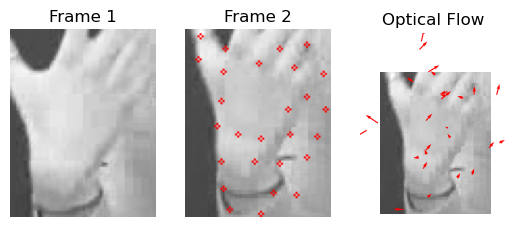

In [10]:
# Load first 2 frames
frame1 = cv2.imread('part1_data/1.png')
frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2 = cv2.imread('part1_data/2.png')
frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

# bounding_boxes = [[93, 272, 56, 83], [201, 270, 56, 83], [154, 102, 67, 115]] #left hand, right hand, head
bounding_boxes = SkinDetect(frame1, mu, sigma)
enlarge = [-10, -10, +20, +20]

# Work with two frames of the left hand
x, y, w, h = np.array(bounding_boxes[0]) + np.array(enlarge)
frame1 = frame1[y:y+h, x:x+w]
frame2 = frame2[y:y+h, x:x+w]

# Convert to grayscale
frame1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
frame2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

# Detect corners
corners = cv2.goodFeaturesToTrack(frame2, maxCorners=100, qualityLevel=0.01, minDistance=10)

# Test function
d_x0, d_y0 = np.zeros(corners.shape[0]), np.zeros(corners.shape[0])
[d_x, d_y] = MultiScaleLucasKanade(frame1, frame2, corners, rho=1, epsilon=0.01, d_x0=d_x0, d_y0=d_y0, num_levels=3)

# Create plot images
frame2_corners = frame2.copy()
frame2_corners = cv2.cvtColor(frame2_corners, cv2.COLOR_GRAY2RGB)
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(frame2_corners, (int(x), int(y)), 1, (255, 0, 0))
x, y = zip(*[corner.ravel() for corner in corners])
frame1RGB = cv2.cvtColor(frame1, cv2.COLOR_GRAY2RGB)
frame2RGB = cv2.cvtColor(frame2, cv2.COLOR_GRAY2RGB)

# Plot the images
plt.subplot(1,3,1)
plt.imshow(frame1RGB)
plt.title('Frame 1')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(frame2_corners)
plt.axis('off')
plt.title('Frame 2')
plt.subplot(1,3,3)
plt.title("Optical Flow")
plt.imshow(cv2.copyMakeBorder(frame2RGB, 0, 0, 0, 0, cv2.BORDER_CONSTANT, value=(255, 255, 255)))
plt.quiver(x-d_x+0, y-d_y+0, -d_x, -d_y, angles='xy', color='r')
plt.axis('off')

print(displ(d_x, d_y, method='threshold'))

Δοκιμάζουμε τον πολυκλιμακωτό Lucas-Kanade σε όλα τα frames

In [11]:
# def TrackSkinMultiScale(rho=1, epsilon=0.1, num_levels=3):
#     # (rho in [1,5], epsilon in [0.01, 0.1])

#     # Load first 2 frames
#     frame1 = cv2.imread('part1_data/1.png')
#     frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
#     frame2 = cv2.imread('part1_data/2.png')
#     frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

#     # Find initial bounding boxes
#     bounding_boxes = SkinDetect(frame1, mu, sigma)
#     enlarge = [-10, -10, +20, +20]
#     bounding_boxes = np.array(bounding_boxes) + np.array(enlarge)

#     # Draw bounding boxes and optical flow
#     image_out = frame1.copy()
#     for box in bounding_boxes:
#         x, y, w, h = box
#         cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
#     dir_path = f'part1_output/1_2_3/p{rho}_e{epsilon}_lvl{num_levels}'.replace('.', '')
#     if not os.path.exists(dir_path):
#         os.makedirs(dir_path)
#     image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
#     cv2.imwrite(dir_path + '/1.png', image_out)

#     # Find optical flow for each bounding box, on each frame
#     i=1
#     while True:
#         # Load first 2 frames
#         frame1 = cv2.imread(f'part1_data/{i}.png')
#         frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
#         frame2 = cv2.imread(f'part1_data/{i+1}.png')
#         if frame2 is None: break
#         frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
#         image_out = frame2.copy()

#         for box in bounding_boxes:
#             # Select frame
#             x, y, w, h = box
#             frame1_box = frame1[y:y+h, x:x+w]
#             frame2_box = frame2[y:y+h, x:x+w]

#             # Convert to grayscale
#             frame1_box = cv2.cvtColor(frame1_box, cv2.COLOR_RGB2GRAY)
#             frame2_box = cv2.cvtColor(frame2_box, cv2.COLOR_RGB2GRAY)

#             # Detect corners
#             corners = cv2.goodFeaturesToTrack(frame2_box, maxCorners=100, qualityLevel=0.01, minDistance=10)

#             # Run Lucas-Kanade
#             d_x0, d_y0 = np.zeros(corners.shape[0]), np.zeros(corners.shape[0])
#             [d_x, d_y] = MultiScaleLucasKanade(frame1_box, frame2_box, corners, rho=rho, epsilon=epsilon, d_x0=d_x0, d_y0=d_y0) #rho=[1,5]

#             # Calculate mean flow
#             [displ_x, displ_y] = displ(d_x, d_y, method='threshold')

#             # Update bounding box
#             box -= np.array([int(displ_x), int(displ_y), 0, 0])
#             box[box<0] = 0

#             # Draw new bounding box and optical flow
#             x, y, w, h = box
#             cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
#             x, y = x+(w//2), y+(h//2)
#             cv2.arrowedLine(image_out, (int(x+displ_x), int(y+displ_y)), (x, y), (255, 0, 0), 1)

#         # Save image
#         image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
#         cv2.imwrite(dir_path+f'/{i+1}.png', image_out)

#         if i%5 ==0: print(f"frame {i+1} done")

#         i+=1

# rhos = [1]
# epsilons = [0.01]
# nums_lvls = [5, 10, 20]
# for rho in rhos:
#     for epsilon in epsilons:
#         for num_lvls in nums_lvls:
#             message = f"Running for rho={rho}, epsilon={epsilon}, num_levels={num_lvls}"
#             print("="*len(message))
#             print(message)
#             print("="*len(message))
#             TrackSkinMultiScale(rho=rho, epsilon=epsilon, num_levels=num_lvls)

Κατασκευάζουμε εικόνες GIF με τα αποτελέσματα, για ευκολότερη σύγκριση

In [12]:
import os
import imageio

def create_gifs_from_directories(parent_directory):
    # Get all child directories in the parent directory
    directories = [d for d in os.listdir(parent_directory) if os.path.isdir(os.path.join(parent_directory, d))]

    # For each directory, create a GIF from the images in the directory
    for directory in directories:
        directory_path = os.path.join(parent_directory, directory)

        # Get all files in the directory
        files = os.listdir(directory_path)

        # Sort files by integer name
        files.sort(key=lambda x: int(os.path.splitext(x)[0]))

        # Create a list to store the images
        images = []

        # Read each image file
        for file in files:
            if file.endswith('.png'):
                filepath = os.path.join(directory_path, file)
                images.append(imageio.imread(filepath))

        # Create GIF
        gif_name = directory + '.gif'
        gif_path = os.path.join(parent_directory, gif_name)
        imageio.mimsave(gif_path, images)

        print(f'GIF saved at: {gif_path}')

# create_gifs_from_directories('part1_output/1_2_2')
create_gifs_from_directories('part1_output/1_2_3')

/home/michael/.conda/envs/cv_lab1_env/lib/python3.7/site-packages/ipykernel_launcher.py:25: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.


GIF saved at: part1_output/1_2_3/p1_e001_lvl2.gif
GIF saved at: part1_output/1_2_3/p1_e001_lvl3.gif
GIF saved at: part1_output/1_2_3/p1_e001_lvl4.gif
GIF saved at: part1_output/1_2_3/p3_e001_lvl2.gif
GIF saved at: part1_output/1_2_3/p3_e001_lvl3.gif
GIF saved at: part1_output/1_2_3/p3_e001_lvl4.gif
GIF saved at: part1_output/1_2_3/p5_e001_lvl2.gif
GIF saved at: part1_output/1_2_3/p5_e001_lvl3.gif
GIF saved at: part1_output/1_2_3/p5_e001_lvl4.gif
GIF saved at: part1_output/1_2_3/p1_e001_lvl5.gif
GIF saved at: part1_output/1_2_3/p1_e001_lvl10.gif
GIF saved at: part1_output/1_2_3/p1_e001_lvl20.gif
